# Feature Scaling & IQR - Complete Practical Guide
### Dataset: California Housing (Popular Kaggle-style Dataset)

This notebook demonstrates:
- IQR (Interquartile Range)
- Outlier Detection
- Feature Scaling Techniques
- Visual comparison before and after scaling

## Load Dataset
We use the California Housing dataset (commonly used in Kaggle competitions).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Interquartile Range (IQR)
IQR measures the spread of the middle 50% of the data.

Formula:
```
IQR = Q3 - Q1
```
Used for detecting outliers:
```
Lower Bound = Q1 - 1.5 * IQR
Upper Bound = Q3 + 1.5 * IQR
```

In [5]:
feature = 'MedInc'
Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower Bound:', lower)
print('Upper Bound:', upper)

Q1: 2.5633999999999997
Q3: 4.74325
IQR: 2.17985
Lower Bound: -0.7063750000000004
Upper Bound: 8.013024999999999


### Boxplot to Visualize Outliers

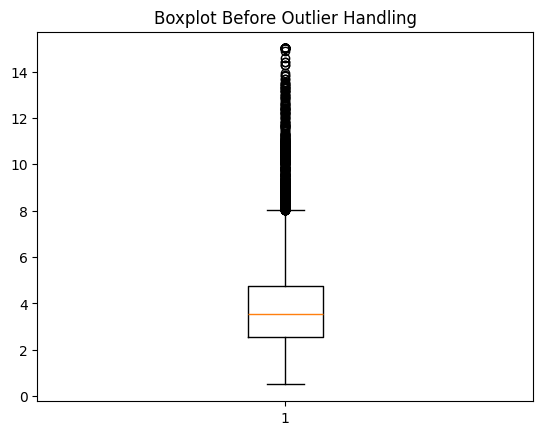

In [6]:
plt.figure()
plt.boxplot(df[feature])
plt.title('Boxplot Before Outlier Handling')
plt.show()

## Feature Scaling Techniques
We will demonstrate:
- MinMaxScaler
- StandardScaler
- RobustScaler
- MaxAbsScaler
- Normalizer

In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler, Normalizer

### Min-Max Scaling

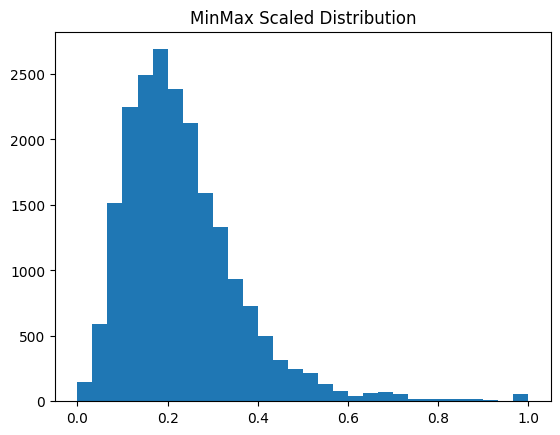

In [8]:
scaler = MinMaxScaler()
df['MedInc_minmax'] = scaler.fit_transform(df[['MedInc']])

plt.figure()
plt.hist(df['MedInc_minmax'], bins=30)
plt.title('MinMax Scaled Distribution')
plt.show()

### Standard Scaling

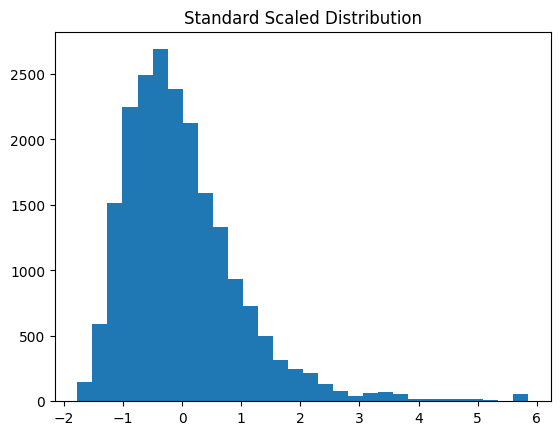

In [9]:
scaler = StandardScaler()
df['MedInc_standard'] = scaler.fit_transform(df[['MedInc']])

plt.figure()
plt.hist(df['MedInc_standard'], bins=30)
plt.title('Standard Scaled Distribution')
plt.show()

### Robust Scaling (Uses IQR)

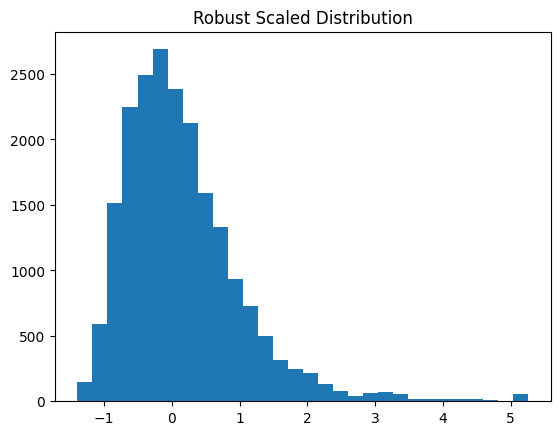

In [10]:
scaler = RobustScaler()
df['MedInc_robust'] = scaler.fit_transform(df[['MedInc']])

plt.figure()
plt.hist(df['MedInc_robust'], bins=30)
plt.title('Robust Scaled Distribution')
plt.show()

### Max Absolute Scaling

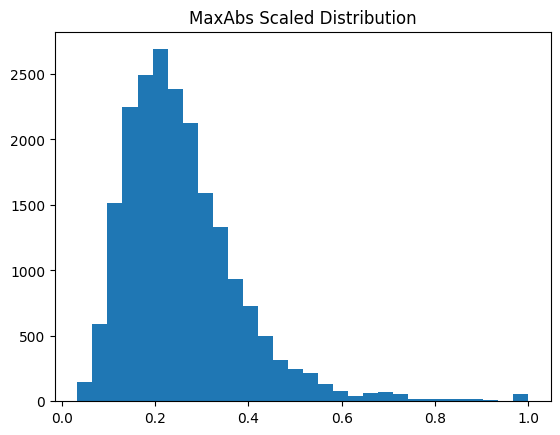

In [11]:
scaler = MaxAbsScaler()
df['MedInc_maxabs'] = scaler.fit_transform(df[['MedInc']])

plt.figure()
plt.hist(df['MedInc_maxabs'], bins=30)
plt.title('MaxAbs Scaled Distribution')
plt.show()

### Normalization (Unit Vector Scaling)

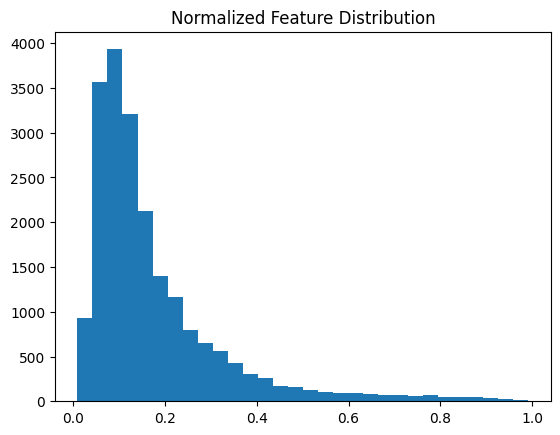

In [12]:
norm = Normalizer()
normed = norm.fit_transform(df[['MedInc','HouseAge']])
norm_df = pd.DataFrame(normed, columns=['MedInc_norm','HouseAge_norm'])

plt.figure()
plt.hist(norm_df['MedInc_norm'], bins=30)
plt.title('Normalized Feature Distribution')
plt.show()